### Look at `HALLA_p` (from E tree) variable for SBS11 LD2 runs [CREATED 02/07/23]
Until now we have been using a beam enrgy number that was put in the GMn run list by the shift crew but that is not precise enough for physics analysis. Hence, I am trying to determine the best was to get the beam energy for all the runs. Observations we make using this script should give us some insight on the above mentioned matter.
#### Issues
1. `HALLA_p` variable that carries the beam energy we get from some EPICS variable can be found in the EPICS tree (E) as well as the T tree. There is a caveat though. EPICS events are only once in 2 seconds or so whereas our event rate is ~ 3.5kHz. As a consequence, we don't have a beam energy value for every physics event. So, it is not a one-to-one mapping between E tree and T tree.
2. Our replay takes care of the above mentioned issue to some extent by recording the same EPICS value for every physics event between two EPICS events. This would mean that we should just be able to use `HALLA_p` variable from T tree two get beam energy every event but there is still another issue. Since, we have recorder huge amount of data every run, our raw data file (.evio) as well as the replay file have several segments per run. Whenever there is a change of segment during replay, podd fills the `HALLA_p` variable with some absurdly large negative number until it fins the first EPICS event. As a result, at the beginning of every segment a bunch of events don't really have a HALLA_p value. Since, we don't really don't store info about the segment number in the tree, surpassing this issue becomes complicated. 

#### Possible Approaches 
1. Defining event range: Andrew's idea, "A better approach is to chain together all the root files from a given run and then define event ranges and beam energy values between EPICS events from the EPICS tree (“E”). For some of the pass 0 and pass 1 replays this method won’t work, since the global event counting is not working properly in earlier versions of SBS-offline/Podd. But that is the scheme you probably want to implement for the final analysis. That method would guarantee that every event after the first EPICS event in any given CODA run will have a valid HALLA_p value (assuming the beam was on when that event was recorded, but that is a separate issue). For the events from the beginning of the run to the first EPICS event you could use the HALLA_p from the first EPICs event."
2. The **easiest approach** is to get an average `HALLA_p` value per run by looping through E tree and use that number for analysis. Here is Andrew's opinion on this, "In the mean time, a safer but arguably less precise approach would be to take the average of all HALLA_p values in the EPICs tree and use that as a single beam energy value for analysis of a given run. Because the EPICs events are “slow” you aren’t really getting an “instantaneous” beam energy that is in sync with the physics events anyway. So just using an average is probably just as good in terms of accuracy."

#### Implementation Ideas
1. For the 2nd approach I want to do the following:
    - Create a CSV file with run number and average HALLA_p values per run for every configuration per target type.
    - Then while looping through the T tree for physics analysis I will grab the run number for every event and read the `HALLA_p` value from the CSV file.
2. For the 1st approach I plan to do the following:
    - Sort by segment numbers before chaining together ROOT files from a given run.
    - For a unique run use the `HALLA_p` branch from tree and then replace the large negative values of the first however many events with the `HALLA_p` value of the last event of previous segment. NOTE: In case of `seg0-0` use a table that contain the first `HALLA_p` value per runnumber.

#### Findings from this Script for SBS11 LD2 Runs
1. Average beam energy vs. run number plot (the error bars represented std) revealed that there are a handful of runs that have much higher spread than the rest of them. 
2. Further investigation revealed that one or two EPICS events of those runs have `HALLA_p` value was recorded as 0! Reason behind this is unkown but it seemed pretty clear that those events were responsible for higher spread and shifting of mean. After filtering out those values from analysis average beam energy and its spread looked quite reasonable across all the runs.
3. Highest spread in `HALLA_p` value within a run is **0.95 MeV**
4. During SBS11 we got one EPICS event roughly every 20K events. This would mean that we get one EPICS event in 8-10 sec, which sounds reasonable. 
5. Several runs have multiple entries for single global event number! 
    - Not sure about the reason yet! Need to further filter the dataset requiring unique event number per run. <span style="color:red">Done</span> 

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hist

In [147]:
sbs11_ld2 = pd.DataFrame(pd.read_csv("get_HALLA_p_prun_SBS11_LD2.csv"))
#sbs11_ld2 = sbs11_ld2.sort_values('evnum') #sort in terms of evnum
sbs11_ld2['HALLA_p_gev'] = sbs11_ld2['HALLA_p'] / 1000.0
sbs11_ld2

,runnum,evnum,HALLA_p,HALLA_p_gev
0,12314,59519,9858.81,9.85881
1,12314,6612514,9858.48,9.85848
2,12314,6639136,9859.47,9.85947
3,12314,6666406,9859.47,9.85947
4,12314,6693627,9858.95,9.85895
...,...,...,...,...
154290,13063,7506572,9859.30,9.85930
154291,13063,680167,9859.08,9.85908
154292,13063,699744,9859.08,9.85908
154293,13063,719585,9859.45,9.85945


In [148]:
fsbs11_ld2 = sbs11_ld2[sbs11_ld2['runnum'] != 12356]
sbs11_ld2_mean_std_p_run_nz = sbs11_ld2.groupby('runnum').agg({'HALLA_p_gev':['mean','std']})
sbs11_ld2_mean_std_p_run_nz = sbs11_ld2_mean_std_p_run_nz.reset_index()
sbs11_ld2_mean_std_p_run_nz.head()

runnum HALLA_p_gev          
                mean       std
0  12314    9.859127  0.000315
1  12315    9.859166  0.000381
2  12316    9.859386  0.000315
3  12318    9.859640  0.000107
4  12319    9.859700  0.000440

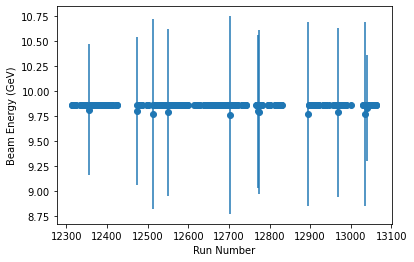

In [149]:
# Plot HALLA_p as a function of run numbers
cut_sigma = sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['std'] < 1 #0.0006
plt.errorbar(sbs11_ld2_mean_std_p_run_nz['runnum'][cut_sigma], sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['mean'][cut_sigma], yerr=sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['std'][cut_sigma], fmt='o')
#plt.xticks(sbs11_ld2_mean_std_p_run_nz['runnum'], rotation=90)
#plt.xlim(12670,12700)
plt.xlabel('Run Number')
plt.ylabel('Beam Energy (GeV)')
plt.show()

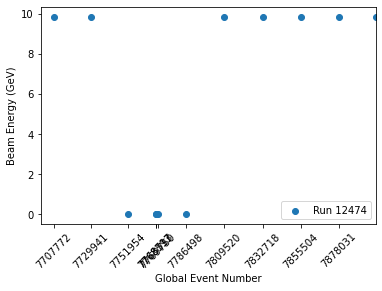

In [150]:
# Plotting HALLA_p as a function of global event numbers to check how often we get scaler events
rnum = sbs11_ld2['runnum'] == 12474 #12371
plt.scatter(x=sbs11_ld2['evnum'][rnum], y=sbs11_ld2['HALLA_p_gev'][rnum], label='Run 12474')
plt.ticklabel_format(style='plain')    # to prevent scientific notation.
plt.xticks(sbs11_ld2['evnum'][rnum], rotation=45)
#plt.xlim(20000,200000)
plt.xlim(7700000,7900000)
plt.xlabel('Global Event Number')
plt.ylabel('Beam Energy (GeV)')
plt.legend()
plt.show()

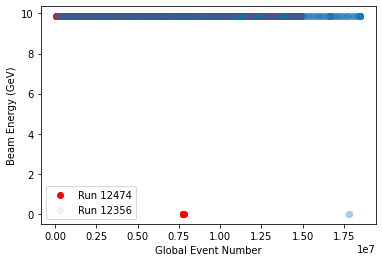

In [151]:
# Again plotting the same as above to get the problematic event
rnum1 = sbs11_ld2['runnum'] == 12474
rnum2 = sbs11_ld2['runnum'] == 12356
plt.scatter(x=sbs11_ld2['evnum'][rnum1], y=sbs11_ld2['HALLA_p_gev'][rnum1], label='Run 12474', color='r')
plt.scatter(x=sbs11_ld2['evnum'][rnum2], y=sbs11_ld2['HALLA_p_gev'][rnum2], label='Run 12356', alpha=0.08)
plt.xlabel('Global Event Number')
plt.ylabel('Beam Energy (GeV)')
plt.legend()
plt.show()

In [152]:
# Getting tables with HALLA_p_mean and HALLA_p_std per run
trun = sbs11_ld2_mean_std_p_run_nz['runnum']
#sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['mean']
tmean = sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['mean']
tstd = sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['std']
tm1 = pd.merge(trun, tmean, left_index=True, right_index=True)
test_table = pd.merge(tm1, tstd, left_index=True, right_index=True)
test_table[test_table['runnum'] == 12687]

,runnum,mean,std
162,12687,9.858031,0.000498


In [153]:
sbs11_ld2[(sbs11_ld2['runnum'] == 12474) & (sbs11_ld2['evnum'] == 7751954)]

,runnum,evnum,HALLA_p,HALLA_p_gev
35959,12474,7751954,0.0,0.0


In [154]:
# Let's filter out all the events where HALLA_p is 0
sbs11_ld2_nonzero_ebeam = sbs11_ld2[sbs11_ld2['HALLA_p'] != 0]
sbs11_ld2_nonzero_ebeam.head()

,runnum,evnum,HALLA_p,HALLA_p_gev
0,12314,59519,9858.81,9.85881
1,12314,6612514,9858.48,9.85848
2,12314,6639136,9859.47,9.85947
3,12314,6666406,9859.47,9.85947
4,12314,6693627,9858.95,9.85895


In [155]:
sbs11_ld2_mean_std_p_run_nz = sbs11_ld2_nonzero_ebeam.groupby('runnum').agg({'HALLA_p_gev':['mean','std']})
sbs11_ld2_mean_std_p_run_nz = sbs11_ld2_mean_std_p_run_nz.reset_index()
sbs11_ld2_mean_std_p_run_nz.head()

runnum HALLA_p_gev          
                mean       std
0  12314    9.859127  0.000315
1  12315    9.859166  0.000381
2  12316    9.859386  0.000315
3  12318    9.859640  0.000107
4  12319    9.859700  0.000440

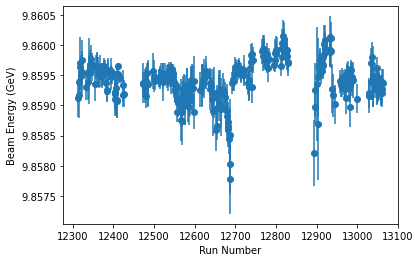

In [156]:
# Plot HALLA_p as a function of run numbers again with non-zero HALLA_p values
cut_sigma = sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['std'] < 1
plt.errorbar(sbs11_ld2_mean_std_p_run_nz['runnum'][cut_sigma], sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['mean'][cut_sigma], yerr=sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['std'][cut_sigma], fmt='o')
#plt.xticks(sbs11_ld2_mean_std_p_run_nz['runnum'], rotation=90)
#plt.xlim(12890,12920)
plt.xlabel('Run Number')
plt.ylabel('Beam Energy (GeV)')
plt.show()

In [157]:
# Getting tables with HALLA_p_mean and HALLA_p_std per run
trun_nz = sbs11_ld2_mean_std_p_run_nz['runnum']
#sbs11_ld2_nonzero_ebeam_mean_std_p_run_nz['HALLA_p_gev']['mean']
tmean_nz = sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['mean']
tstd_nz = sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['std']
tm1_nz = pd.merge(trun_nz, tmean_nz, left_index=True, right_index=True)
test_table_nz = pd.merge(tm1_nz, tstd_nz, left_index=True, right_index=True)
test_table_nz.columns = ['runnum', 'ebeam_mean', 'ebeam_std']
test_table_nz.head()

,runnum,ebeam_mean,ebeam_std
0,12314,9.859127,0.000315
1,12315,9.859166,0.000381
2,12316,9.859386,0.000315
3,12318,9.859640,0.000107
4,12319,9.859700,0.000440


In [158]:
# write out a csv file
#test_table_nz.to_csv('sbs11_ld2_nonzero_ebeam_ebeam.csv', index=False)

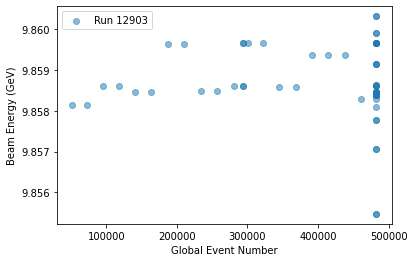

In [159]:
rnum1 = sbs11_ld2_nonzero_ebeam['runnum'] == 12902
rnum2 = sbs11_ld2_nonzero_ebeam['runnum'] == 12903
#plt.scatter(x=sbs11_ld2_nonzero_ebeam['evnum'][rnum1], y=sbs11_ld2_nonzero_ebeam['HALLA_p_gev'][rnum1], label='Run 12902', color='r')
plt.scatter(x=sbs11_ld2_nonzero_ebeam['evnum'][rnum2], y=sbs11_ld2_nonzero_ebeam['HALLA_p_gev'][rnum2], label='Run 12903', alpha=0.5)
plt.xlabel('Global Event Number')
plt.ylabel('Beam Energy (GeV)')
#plt.xticks(sbs11_ld2_nonzero_ebeam['evnum'][rnum2], rotation=45)
#plt.xlim(2800000,2805000)
plt.legend()
plt.show()

In [160]:
sbs11_ld2_nonzero_ebeam[(sbs11_ld2_nonzero_ebeam['runnum'] == 12903)]

,runnum,evnum,HALLA_p,HALLA_p_gev
118343,12903,51509,9858.15,9.85815
118344,12903,73079,9858.15,9.85815
118345,12903,94968,9858.61,9.85861
118346,12903,117498,9858.61,9.85861
118347,12903,140409,9858.47,9.85847
118348,12903,163555,9858.47,9.85847
118349,12903,186846,9859.64,9.85964
118350,12903,210398,9859.64,9.85964
118351,12903,234013,9858.49,9.85849
118352,12903,257513,9858.49,9.85849


In [161]:
# Total no of EPICS events per run
nevents_epics = sbs11_ld2_nonzero_ebeam['runnum'].value_counts().reset_index()
nevents_epics_df = pd.DataFrame(nevents_epics)
nevents_epics_df.columns = ['runnum', 'nevents']
#nevents_epics.to_frame() # this is not working! No clue why!
nevents_epics_df[nevents_epics_df['runnum'] == 12314]

,runnum,nevents
22,12314,754


In [162]:
sbs11_ld2_nonzero_ebeam_nd = sbs11_ld2_nonzero_ebeam.drop_duplicates(subset=['runnum', 'evnum'], keep='first')
sbs11_ld2_nonzero_ebeam_nd[(sbs11_ld2_nonzero_ebeam_nd['runnum'] == 12903)]

,runnum,evnum,HALLA_p,HALLA_p_gev
118343,12903,51509,9858.15,9.85815
118344,12903,73079,9858.15,9.85815
118345,12903,94968,9858.61,9.85861
118346,12903,117498,9858.61,9.85861
118347,12903,140409,9858.47,9.85847
118348,12903,163555,9858.47,9.85847
118349,12903,186846,9859.64,9.85964
118350,12903,210398,9859.64,9.85964
118351,12903,234013,9858.49,9.85849
118352,12903,257513,9858.49,9.85849


In [163]:
# Total no of EPICS events per run after filtering duplicate entries
nevents_epics_nd = sbs11_ld2_nonzero_ebeam_nd['runnum'].value_counts().reset_index()
nevents_epics_nd_df = pd.DataFrame(nevents_epics_nd)
nevents_epics_nd_df.columns = ['runnum', 'nevents']
#nevents_epics.to_frame() # this is not working! No clue why!
nevents_epics_nd_df[nevents_epics_nd_df['runnum'] == 12314]

,runnum,nevents
22,12314,754


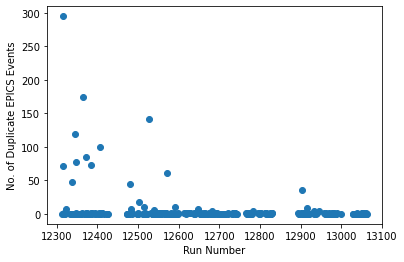

In [164]:
ndup_prun = pd.merge(nevents_epics_df, nevents_epics_nd_df, on='runnum', suffixes=('', '_ndup'))
ndup_prun['ndup'] = ndup_prun['nevents'] - ndup_prun['nevents_ndup']
plt.scatter(x=ndup_prun['runnum'], y=ndup_prun['ndup'])
plt.xlabel('Run Number')
plt.ylabel('No. of Duplicate EPICS Events')
plt.show()

In [165]:
sbs11_ld2_mean_std_p_run_nz_nd = sbs11_ld2_nonzero_ebeam_nd.groupby('runnum').agg({'HALLA_p_gev':['mean','std']})
sbs11_ld2_mean_std_p_run_nz_nd = sbs11_ld2_mean_std_p_run_nz_nd.reset_index()
sbs11_ld2_mean_std_p_run_nz_nd.head()

runnum HALLA_p_gev          
                mean       std
0  12314    9.859127  0.000315
1  12315    9.859130  0.000392
2  12316    9.859312  0.000315
3  12318    9.859640  0.000108
4  12319    9.859700  0.000440

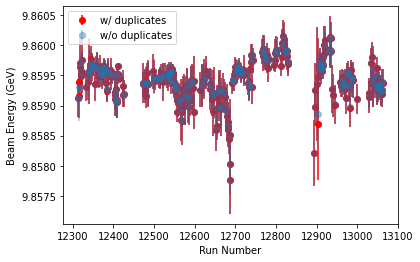

In [166]:
# Plot HALLA_p as a function of run numbers again with non-zero HALLA_p values and no duplicate EPICS events
cut_sigma = sbs11_ld2_mean_std_p_run_nz_nd['HALLA_p_gev']['std'] < 1
plt.errorbar(sbs11_ld2_mean_std_p_run_nz['runnum'][cut_sigma], sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['mean'][cut_sigma], yerr=sbs11_ld2_mean_std_p_run_nz['HALLA_p_gev']['std'][cut_sigma], fmt='o', color='r', label='w/ duplicates')
plt.errorbar(sbs11_ld2_mean_std_p_run_nz_nd['runnum'][cut_sigma], sbs11_ld2_mean_std_p_run_nz_nd['HALLA_p_gev']['mean'][cut_sigma], yerr=sbs11_ld2_mean_std_p_run_nz_nd['HALLA_p_gev']['std'][cut_sigma], fmt='o', alpha=0.4, label='w/o duplicates')
#plt.xticks(sbs11_ld2_mean_std_p_run_nz_nd['runnum'], rotation=90)
#plt.xlim(12650,12700)
plt.legend()
plt.xlabel('Run Number')
plt.ylabel('Beam Energy (GeV)')
plt.show()

In [167]:
# Getting tables with HALLA_p_mean and HALLA_p_std per run and saving the values in a CSV file
trun_nz_nd = sbs11_ld2_mean_std_p_run_nz_nd['runnum']
#sbs11_ld2_nonzero_ebeam_mean_std_p_run_nz_nd['HALLA_p_gev']['mean']
tmean_nz_nd = sbs11_ld2_mean_std_p_run_nz_nd['HALLA_p_gev']['mean']
tstd_nz_nd = sbs11_ld2_mean_std_p_run_nz_nd['HALLA_p_gev']['std']
tm1_nz_nd = pd.merge(trun_nz_nd, tmean_nz_nd, left_index=True, right_index=True)
test_table_nz_nd = pd.merge(tm1_nz_nd, tstd_nz_nd, left_index=True, right_index=True)
test_table_nz_nd.columns = ['runnum', 'ebeam_mean', 'ebeam_std']
test_table_nz_nd.head()
# write out a csv file
test_table_nz_nd.to_csv('../../DB/sbs11_LD2_avg_ebeam_prun.csv', index=False)

In [168]:
#test_table_nz_nd['ebeam_std'].max() - test_table_nz['ebeam_std'].max()
test_table_nz_nd['ebeam_mean'].mean()

9.859416685750016